# Exp 4: Global vs YOLO — Best Backbone + DistilBERT + Concat + MLP

**Goal:** Using the best backbone from Exp 3, compare global vs YOLO image representations.

**Hyperparameters:** Auto-loaded per variant from `results/tuning/exp4_{variant}_best_params.json`.

**Note:** Requires `results/exp3.json` — run Exp 3 first.

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json, os, copy
import warnings

warnings.filterwarnings('ignore')

ROOT = Path("../../").parent.resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Root path: {ROOT}')

Using device: mps
Root path: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


## 1. Load Best Backbone from Exp 3

In [2]:
assert (ROOT / 'results/exp3.json').exists(), 'Run exp3 first!'
exp3 = json.load(open(ROOT / 'results/exp3.json'))

BEST_BB  = exp3['best_image_backbone']
IMG_DIM  = exp3['best_img_dim']
print(f'Best backbone: {BEST_BB.upper()} (dim={IMG_DIM})')
for k, v in exp3['results'].items():
    marker = ' <- winner' if k == BEST_BB else ''
    print(f'  {k}: AUC = {v["dev_auc_roc"]:.4f}{marker}')

Best backbone: VIT (dim=768)
  resnet50: AUC = 0.6482
  vit: AUC = 0.6690 <- winner


## 2. Load Embeddings

In [3]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'

IMG_KEYS = {'global': BEST_BB, 'yolo': f'{BEST_BB}_yolo'}

raw = {}
for variant, img_key in IMG_KEYS.items():
    Xi_tr = np.load(IMG_DIR  / f'train_{img_key}.npy').astype(np.float32)
    Xt_tr = np.load(TEXT_DIR / 'train_distilbert.npy').astype(np.float32)
    y_tr  = np.load(IMG_DIR  / 'train_labels.npy')
    Xi_dv = np.load(IMG_DIR  / f'dev_{img_key}.npy').astype(np.float32)
    Xt_dv = np.load(TEXT_DIR / 'dev_distilbert.npy').astype(np.float32)
    y_dv  = np.load(IMG_DIR  / 'dev_labels.npy')
    sci   = StandardScaler().fit(Xi_tr)
    sct   = StandardScaler().fit(Xt_tr)
    raw[variant] = (sci.transform(Xi_tr), sct.transform(Xt_tr), y_tr,
                    sci.transform(Xi_dv), sct.transform(Xt_dv), y_dv)
    print(f'[{variant}] img={Xi_tr.shape}')

y_train    = raw['global'][2]
pos_weight = torch.tensor([(y_train==0).sum() / (y_train==1).sum()],
                           dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.3f}')

[global] img=(8500, 768)
[yolo] img=(8500, 768)
pos_weight: 1.787


## 3. Load Tuned Hyperparameters (per variant)

In [4]:
DEFAULTS = {'proj_dim': 256, 'hidden1': 128, 'hidden2': 32,
            'dropout_proj': 0.3, 'dropout1': 0.3, 'dropout2': 0.2,
            'lr': 1e-4, 'weight_decay': 1e-3}

tuned_params = {}
for variant in ['global', 'yolo']:
    path = ROOT / f'results/tuning/exp4_{variant}_best_params.json'
    if path.exists():
        tuned_params[variant] = json.load(open(path))['params']
        print(f'{variant}: loaded tuned params -> {tuned_params[variant]}')
    else:
        tuned_params[variant] = DEFAULTS.copy()
        print(f'{variant}: tuning not found — using defaults')

global: loaded tuned params -> {'proj_dim': 128, 'hidden1': 256, 'hidden2': 32, 'dropout_proj': 0.16246081210169555, 'dropout1': 0.24417840790003886, 'dropout2': 0.3269194065331371, 'lr': 0.0004860384085106945, 'weight_decay': 0.005134837517177728}
yolo: loaded tuned params -> {'proj_dim': 512, 'hidden1': 128, 'hidden2': 64, 'dropout_proj': 0.29094033367128297, 'dropout1': 0.31405481791583323, 'dropout2': 0.1668553738271178, 'lr': 0.000580459829042945, 'weight_decay': 9.08064126912784e-05}


## 4. DataLoaders

In [5]:
BATCH_SIZE = 64

def make_loader(Xi, Xt, y, shuffle=False):
    ds = TensorDataset(torch.tensor(Xi, dtype=torch.float32),
                       torch.tensor(Xt, dtype=torch.float32),
                       torch.tensor(y,  dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

loaders = {}
for variant in ['global', 'yolo']:
    Xi_tr, Xt_tr, y_tr, Xi_dv, Xt_dv, y_dv = raw[variant]
    loaders[variant] = {'train': make_loader(Xi_tr, Xt_tr, y_tr, shuffle=True),
                        'dev':   make_loader(Xi_dv, Xt_dv, y_dv)}
print('DataLoaders ready.')

DataLoaders ready.


## 5. Model

In [6]:
class ProjectionFusionMLP(nn.Module):
    def __init__(self, img_dim, text_dim=768, proj_dim=256,
                 d_proj=0.3, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(img_dim,  proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),           nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x_img, x_text):
        return self.classifier(
            torch.cat([self.img_proj(x_img), self.text_proj(x_text)], dim=-1)
        ).squeeze(-1)

## 6. Train Both Variants

In [7]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_img, x_text, y in loader:
            x_img, x_text, y = x_img.to(DEVICE), x_text.to(DEVICE), y.to(DEVICE)
            logits = model(x_img, x_text)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


def train_model(variant, epochs=50, patience=10):
    p = tuned_params[variant]
    label = f'{BEST_BB.upper()} [{variant.upper()}] + DistilBERT'
    print(f'\n{"="*55}\nTraining: {label}\nParams: {p}\n{"="*55}')

    model = ProjectionFusionMLP(
        img_dim=IMG_DIM, proj_dim=p['proj_dim'],
        d_proj=p['dropout_proj'], h1=p['hidden1'], h2=p['hidden2'],
        d1=p['dropout1'], d2=p['dropout2']
    ).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
    best_auc, best_state, patience_ctr = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_auc, tr_acc, _, _ = run_epoch(loaders[variant]['train'], model, criterion, optimizer)
        dv_loss, dv_auc, dv_acc, _, _ = run_epoch(loaders[variant]['dev'],   model, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
        history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

        if dv_auc > best_auc:
            best_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0; flag = '  <- best'
        else:
            patience_ctr += 1; flag = f'  (patience {patience_ctr}/{patience})'

        print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
              f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch}'); break

    print(f'Best Dev AUC: {best_auc:.4f}')
    model.load_state_dict(best_state)
    return model, history, best_auc


results = {}
histories = {}
trained_models = {}

for variant in ['global', 'yolo']:
    model, history, _ = train_model(variant)
    trained_models[variant] = model
    histories[variant] = history
    _, dev_auc, dev_acc, _, _ = run_epoch(loaders[variant]['dev'], model,
                                           nn.BCEWithLogitsLoss(pos_weight=pos_weight))
    results[variant] = {'dev_auc_roc': round(float(dev_auc), 4),
                        'dev_accuracy': round(float(dev_acc), 4)}


Training: VIT [GLOBAL] + DistilBERT
Params: {'proj_dim': 128, 'hidden1': 256, 'hidden2': 32, 'dropout_proj': 0.16246081210169555, 'dropout1': 0.24417840790003886, 'dropout2': 0.3269194065331371, 'lr': 0.0004860384085106945, 'weight_decay': 0.005134837517177728}
Ep 01 | Tr Loss 0.8216 AUC 0.6832 | Dev Loss 1.0584 AUC 0.6229 Acc 0.5860  <- best
Ep 02 | Tr Loss 0.7408 AUC 0.7674 | Dev Loss 1.0472 AUC 0.6416 Acc 0.5780  <- best
Ep 03 | Tr Loss 0.6736 AUC 0.8180 | Dev Loss 1.1297 AUC 0.6437 Acc 0.6060  <- best
Ep 04 | Tr Loss 0.6097 AUC 0.8558 | Dev Loss 1.1683 AUC 0.6347 Acc 0.5780  (patience 1/10)
Ep 05 | Tr Loss 0.5482 AUC 0.8851 | Dev Loss 1.2726 AUC 0.6534 Acc 0.5980  <- best
Ep 06 | Tr Loss 0.5003 AUC 0.9052 | Dev Loss 1.3278 AUC 0.6359 Acc 0.5820  (patience 1/10)
Ep 07 | Tr Loss 0.4424 AUC 0.9259 | Dev Loss 1.5859 AUC 0.6345 Acc 0.5700  (patience 2/10)
Ep 08 | Tr Loss 0.3973 AUC 0.9401 | Dev Loss 1.6408 AUC 0.6396 Acc 0.5840  (patience 3/10)
Ep 09 | Tr Loss 0.3731 AUC 0.9469 | Dev L

## 7. Training Curves

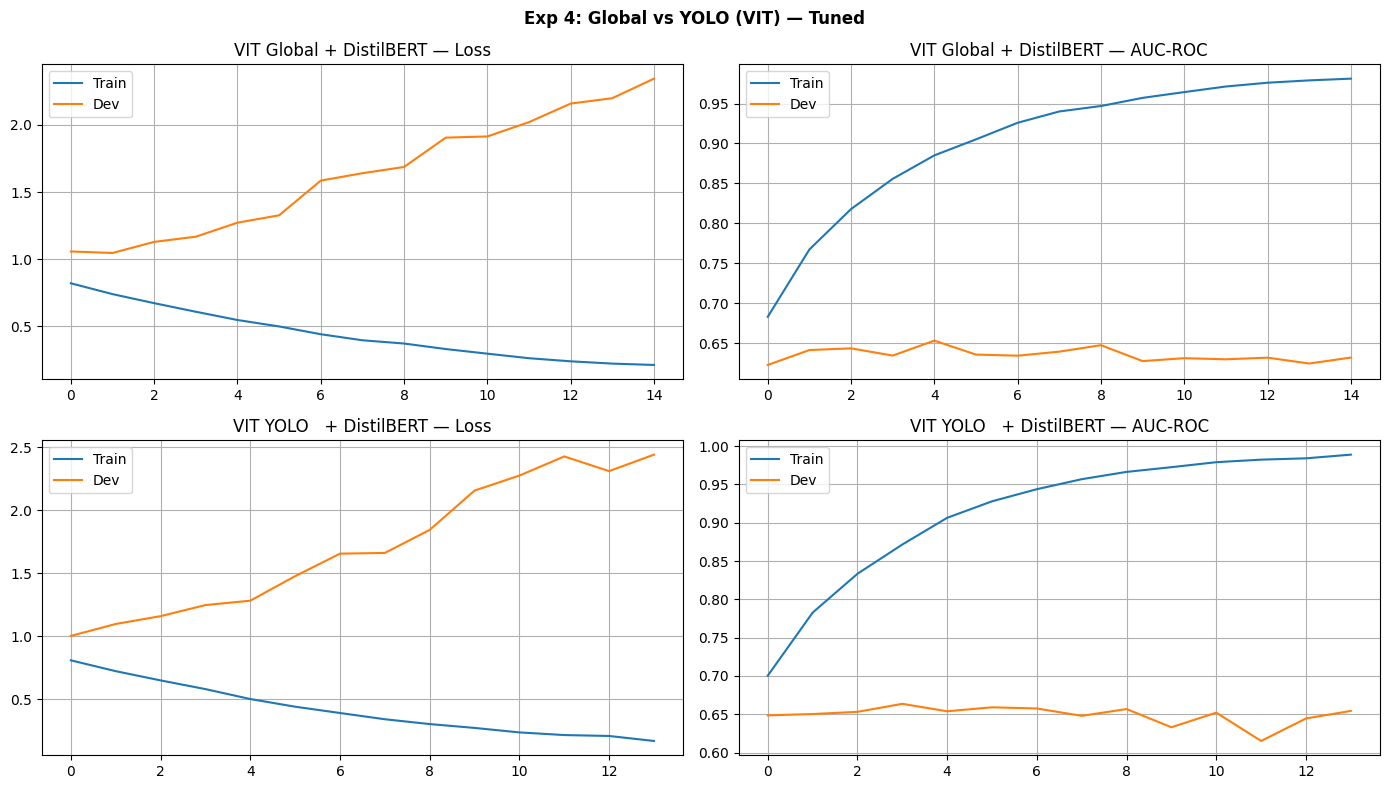

In [8]:
os.makedirs(ROOT / 'outputs', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
vlabels = {'global': f'{BEST_BB.upper()} Global + DistilBERT',
           'yolo':   f'{BEST_BB.upper()} YOLO   + DistilBERT'}

for row, variant in enumerate(['global', 'yolo']):
    h = histories[variant]
    axes[row,0].plot(h['train_loss'], label='Train'); axes[row,0].plot(h['dev_loss'], label='Dev')
    axes[row,0].set_title(f'{vlabels[variant]} — Loss'); axes[row,0].legend(); axes[row,0].grid(True)
    axes[row,1].plot(h['train_auc'],  label='Train'); axes[row,1].plot(h['dev_auc'],  label='Dev')
    axes[row,1].set_title(f'{vlabels[variant]} — AUC-ROC'); axes[row,1].legend(); axes[row,1].grid(True)

plt.suptitle(f'Exp 4: Global vs YOLO ({BEST_BB.upper()}) — Tuned', fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/04_training_curves.png', dpi=150)
plt.show()

## 8. Results & Representation Selection

In [9]:
print('=' * 60)
print(f'EXP 4 — Global vs YOLO ({BEST_BB.upper()}) | Dev Set')
print('=' * 60)
for variant in ['global', 'yolo']:
    r = results[variant]
    print(f'  {vlabels[variant]:42s}: AUC = {r["dev_auc_roc"]:.4f}  Acc = {r["dev_accuracy"]:.4f}')

best_repr = max(results, key=lambda k: results[k]['dev_auc_roc'])
delta     = results['yolo']['dev_auc_roc'] - results['global']['dev_auc_roc']
print(f'\n-> Best representation: {BEST_BB.upper()} [{best_repr.upper()}]')
print(f'   YOLO vs Global delta : {delta:+.4f}')
if abs(delta) <= 0.005:
    print('   -> Negligible difference')
elif delta > 0:
    print('   -> YOLO crops add signal')
else:
    print('   -> Global embedding is better')

EXP 4 — Global vs YOLO (VIT) | Dev Set
  VIT Global + DistilBERT                   : AUC = 0.6534  Acc = 0.5980
  VIT YOLO   + DistilBERT                   : AUC = 0.6636  Acc = 0.6260

-> Best representation: VIT [YOLO]
   YOLO vs Global delta : +0.0102
   -> YOLO crops add signal


## 9. Classification Report — Best Variant

In [10]:
_, _, _, best_probs, best_true = run_epoch(
    loaders[best_repr]['dev'], trained_models[best_repr],
    nn.BCEWithLogitsLoss(pos_weight=pos_weight)
)
print(classification_report(best_true, (best_probs >= 0.5).astype(int),
                             target_names=['Not Hateful', 'Hateful']))

              precision    recall  f1-score   support

 Not Hateful       0.59      0.81      0.68       250
     Hateful       0.70      0.44      0.54       250

    accuracy                           0.63       500
   macro avg       0.65      0.63      0.61       500
weighted avg       0.65      0.63      0.61       500



## 10. Save Models & Results

In [11]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'results', exist_ok=True)

for variant in ['global', 'yolo']:
    torch.save(trained_models[variant].state_dict(),
               ROOT / f'models/04_{BEST_BB}_{variant}_distilbert_concat_mlp.pt')

exp4_out = {
    'experiment': '04_GlobalVsYOLO',
    'backbone': BEST_BB, 'img_dim': IMG_DIM,
    'text_backbone': 'DistilBERT CLS (768-dim)',
    'results': results,
    'best_image_representation': best_repr,
    'best_image_key': IMG_KEYS[best_repr]
}
with open(ROOT / 'results/exp4.json', 'w') as f:
    json.dump(exp4_out, f, indent=2)

print('Saved models and results/exp4.json')
print(json.dumps(exp4_out, indent=2))

Saved models and results/exp4.json
{
  "experiment": "04_GlobalVsYOLO",
  "backbone": "vit",
  "img_dim": 768,
  "text_backbone": "DistilBERT CLS (768-dim)",
  "results": {
    "global": {
      "dev_auc_roc": 0.6534,
      "dev_accuracy": 0.598
    },
    "yolo": {
      "dev_auc_roc": 0.6636,
      "dev_accuracy": 0.626
    }
  },
  "best_image_representation": "yolo",
  "best_image_key": "vit_yolo"
}
